<a href="https://colab.research.google.com/github/jwlee95/DSP_w_Python2026/blob/main/PDSP_Ch01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1장 예제:

연속신호 근사 곡선과 표본화된 이산신호를 함께 생성하고 시각화한다.   
필요 라이브러리: numpy, matplotlib


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

이 셀은 파이썬 라이브러리를 가져오는(import) 역할을 합니다. 외부 라이브러리의 기능을 사용하기 위해서는 먼저 해당 라이브러리를 현재 스크립트나 노트북으로 불러와야 합니다.

*   `import numpy as np`:
    *   **numpy**는 'Numerical Python'의 줄임말로, 파이썬에서 대규모 다차원 배열을 효율적으로 처리하고 수치 계산을 수행하는 데 필수적인 라이브러리입니다. 수학적 연산, 선형대수, 푸리에 변환 등에 널리 사용됩니다.
    *   `as np`는 numpy 라이브러리를 사용할 때마다 `numpy.`라고 길게 쓰는 대신 `np.`라는 짧은 별칭으로 사용할 수 있도록 합니다. 이는 코드의 가독성과 작성 편의성을 높여줍니다.

*   `import matplotlib.pyplot as plt`:
    *   **matplotlib**는 파이썬에서 데이터를 시각화하는 데 사용되는 가장 널리 사용되는 라이브러리 중 하나입니다. 그래프, 차트, 플롯 등을 생성하는 데 강력한 기능을 제공합니다.
    *   **pyplot**은 matplotlib의 한 모듈로, MATLAB과 유사한 방식으로 플롯을 쉽게 생성할 수 있는 인터페이스를 제공합니다.
    *   `as plt`는 matplotlib.pyplot 모듈을 사용할 때 `plt.`라는 별칭으로 사용할 수 있도록 하여 코드를 간결하게 만듭니다.

이러한 `import` 문 덕분에 우리는 `np.array()`와 같은 넘파이 함수나 `plt.plot()`와 같은 matplotlib 플로팅 함수를 사용할 수 있게 됩니다.

In [ ]:
def generate_continuous_and_sampled_sine(A: float, f0: float, phi: float,
                                          fs: float, duration: float,
                                          n_cont: int = 2000):
    """
    사인파 x(t) = A*cos(2*pi*f0*t + phi)에 대하여,
    연속신호 근사 곡선과 fs[Hz]로 표본화한 이산신호를 동시에 생성한다.

    Parameters
    ----------
    A : 진폭(amplitude)
    f0 : 신호 주파수(Hz)
    phi : 위상(rad)
    fs : 표본화 주파수(sampling frequency, Hz)
    duration : 측정 시간(s)
    n_cont : 연속신호 근사를 위한 점의 개수 (기본값 2000)

    Returns
    -------
    t_cont, x_cont : 연속신호 근사를 위한 시간 벡터와 신호 값
    t_samp, x_samp : 표본화된 이산신호의 시간 벡터와 신호 값
    """
    t_cont = np.linspace(0, duration, n_cont)
    x_cont = A * np.cos(2 * np.pi * f0 * t_cont + phi)

    n = np.arange(0, int(fs * duration) + 1)
    t_samp = n / fs
    x_samp = A * np.cos(2 * np.pi * f0 * t_samp + phi)

    return t_cont, x_cont, t_samp, x_samp

## `generate_continuous_and_sampled_sine` 함수 설명

이 함수는 사인파 신호를 연속 신호의 근사치와 이산 샘플링된 신호 두 가지 형태로 생성합니다.

### 1. 연속 신호 근사 (Continuous Signal Approximation)

사인파의 일반적인 수학적 표현은 다음과 같습니다:

$$x(t) = A \cos(2\pi f_0 t + \phi)$$

*   $A$: 진폭 (amplitude)
*   $f_0$: 신호 주파수 (Hz)
*   $t$: 시간 (s)
*   $\phi$: 위상 (radians)

이 함수에서는 `np.linspace(0, duration, n_cont)`를 사용하여 `0`부터 `duration`까지 `n_cont`개의 균일한 시간점 `t_cont`를 생성합니다. 그리고 이 `t_cont` 값들을 위 수식에 대입하여 연속 신호의 근사값 `x_cont`를 계산합니다.

### 2. 이산 샘플링된 신호 (Discrete Sampled Signal)

연속 신호 $x(t)$를 샘플링 주파수 $f_s$로 샘플링하면 이산 신호 $x[n]$을 얻을 수 있습니다. 여기서 $n$은 샘플 인덱스이며, 각 샘플 시간 $t_n$은 $n/f_s$로 주어집니다.

$$x[n] = x(n T_s) = A \cos(2\pi f_0 (n/f_s) + \phi)$$

*   $n$: 샘플 번호 (0, 1, 2, ...)
*   $f_s$: 샘플링 주파수 (Hz)
*   $T_s = 1/f_s$: 샘플링 주기 (s)

이 함수에서는 `np.arange(0, int(fs * duration) + 1)`를 사용하여 샘플 인덱스 `n`을 생성합니다. 그리고 이 `n`과 `fs`를 이용하여 각 샘플의 시간 `t_samp = n / fs`를 계산하고, 이를 위 이산 신호 수식에 대입하여 이산 신호 값 `x_samp`를 얻습니다.

In [ ]:
def plot_continuous_vs_sampled(t_cont, x_cont, t_samp, x_samp, f0, fs):
    """연속신호 근사 곡선과 표본점을 흰색 배경의 그래프 위에 함께 그린다."""
    fig, ax = plt.subplots(figsize=(8, 4), facecolor='white')
    ax.set_facecolor('white')

    ax.plot(t_cont, x_cont, color='black', linewidth=1.5,
            label='x(t), continuous')
    ax.stem(t_samp, x_samp, linefmt='b-', markerfmt='bo', basefmt=' ',
            label='x[n], sampled')

    ax.set_xlabel('Time t (s)')
    ax.set_ylabel('Amplitude x(t)')
    ax.set_title(f'Sine wave (f0 = {f0} Hz) sampled at fs = {fs} Hz')
    ax.legend(loc='upper right')
    ax.grid(True, linewidth=0.5, alpha=0.5)

    fig.tight_layout()
    plt.show()

## `plot_continuous_vs_sampled` 함수 설명

이 함수는 연속 신호의 근사 곡선과 해당 신호에서 샘플링된 이산점을 하나의 그래프 위에 시각화합니다. 이를 통해 샘플링 과정과 그 결과를 직관적으로 이해할 수 있도록 돕습니다.

### 함수 인자 (Parameters)

*   `t_cont`: 연속 신호 근사를 위한 시간 벡터입니다. `generate_continuous_and_sampled_sine` 함수에서 반환된 `t_cont`와 동일합니다.
*   `x_cont`: 연속 신호 근사를 위한 신호 값입니다. `generate_continuous_and_sampled_sine` 함수에서 반환된 `x_cont`와 동일합니다.
*   `t_samp`: 표본화된 이산 신호의 시간 벡터입니다. `generate_continuous_and_sampled_sine` 함수에서 반환된 `t_samp`와 동일합니다.
*   `x_samp`: 표본화된 이산 신호의 신호 값입니다. `generate_continuous_and_sampled_sine` 함수에서 반환된 `x_samp`와 동일합니다.
*   `f0`: 원본 사인파의 주파수(Hz)로, 그래프 제목에 표시됩니다.
*   `fs`: 샘플링 주파수(Hz)로, 그래프 제목에 표시됩니다.

### 주요 기능

1.  **그래프 설정**: `matplotlib.pyplot`을 사용하여 그림(figure)과 축(axis) 객체를 생성하고, 배경색을 흰색으로 설정합니다.
2.  **연속 신호 플롯**: `ax.plot()`을 사용하여 `t_cont`와 `x_cont`를 검은색 선으로 그려 연속 신호의 형태를 보여줍니다.
3.  **이산 신호 스템 플롯**: `ax.stem()`을 사용하여 `t_samp`와 `x_samp`를 파란색 '줄기(stem)' 형태로 그려 샘플링된 각 지점과 그 값을 명확하게 표시합니다. 이는 이산 신호를 표현할 때 유용합니다.
4.  **레이블 및 제목**: x축('Time t (s)'), y축('Amplitude x(t)') 레이블과 함께 신호 주파수(`f0`)와 샘플링 주파수(`fs`)를 포함하는 제목을 설정하여 그래프의 내용을 설명합니다.
5.  **범례 (Legend)**: 그래프에 표시된 연속 신호와 이산 신호에 대한 범례를 추가하여 각 요소가 무엇을 나타내는지 쉽게 구분할 수 있도록 합니다.
6.  **그리드**: 가독성을 높이기 위해 그리드를 추가합니다.
7.  **레이아웃 조정 및 표시**: `fig.tight_layout()`으로 그래프 요소들이 잘리지 않도록 레이아웃을 자동으로 조정하고, `plt.show()`를 호출하여 최종 그래프를 화면에 출력합니다.

---
## `if __name__ == "__main__":` 블록 설명

이 코드는 파이썬 스크립트나 모듈에서 일반적으로 사용되는 패턴입니다. 이 조건문 안에 있는 코드는 현재 파일이 직접 실행될 때만 실행되고, 다른 파일에서 모듈로 임포트될 때는 실행되지 않도록 합니다.

#### `if __name__ == "__main__":` 의 의미

*   `__name__`은 파이썬 내장 변수로, 현재 모듈의 이름을 담고 있습니다.
*   파일이 직접 실행될 때 `__name__` 변수에는 `"__main__"` 문자열이 할당됩니다.
*   파일이 다른 파일에 의해 모듈로 임포트될 때 `__name__` 변수에는 해당 모듈의 실제 이름(예: `my_module`)이 할당됩니다.

따라서 `if __name__ == "__main__":` 조건문은 "이 스크립트가 메인 프로그램으로 실행될 때만 다음 코드를 실행하라"는 의미가 됩니다.

#### 이 블록 안의 코드 설명

이 블록 안에서는 사인파를 생성하고 시각화하기 위한 일련의 작업이 수행됩니다.

1.  **변수 정의**: 사인파의 특성(`A`, `f0`, `phi`)과 샘플링 환경(`fs`, `duration`)을 정의합니다.
    *   `A, f0, phi = 1.0, 5.0, 0.0`: 진폭(Amplitude) 1.0, 주파수(Frequency) 5.0 Hz, 위상(Phase) 0.0 라디안으로 설정합니다.
    *   `fs, duration = 50.0, 1.0`: 샘플링 주파수(Sampling Frequency)를 50.0 Hz로, 신호 지속 시간(Duration)을 1.0 초로 설정합니다.

2.  **사인파 신호 생성**: 이전에 정의된 `generate_continuous_and_sampled_sine` 함수를 호출하여 연속 신호 근사값(`t_cont`, `x_cont`)과 이산 샘플링된 신호(`t_samp`, `x_samp`)를 생성합니다.
    ```python
    t_cont, x_cont, t_samp, x_samp = generate_continuous_and_sampled_sine(
        A, f0, phi, fs, duration
    )
    ```

3.  **생성된 신호 시각화**: 이전에 정의된 `plot_continuous_vs_sampled` 함수를 호출하여 생성된 연속 신호와 이산 신호를 하나의 그래프 위에 시각화합니다.
    ```python
    plot_continuous_vs_sampled(t_cont, x_cont, t_samp, x_samp, f0, fs)
    ```

결론적으로, 이 `if __name__ == "__main__":` 블록은 이 노트북 파일이 실행될 때 사인파 생성 및 시각화 예제를 즉시 실행할 수 있도록 하는 진입점(entry point) 역할을 합니다.

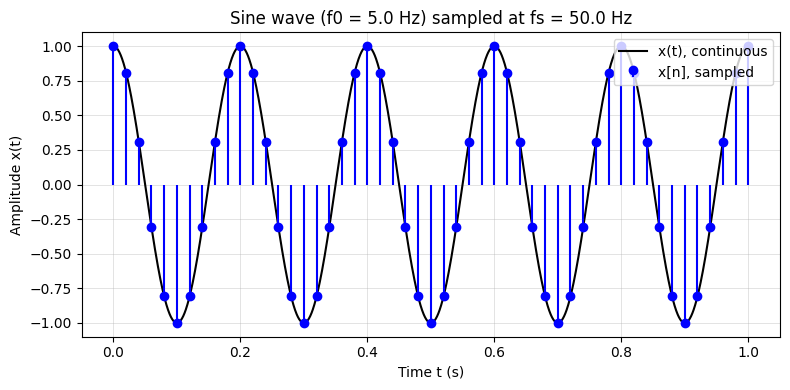

In [ ]:

if __name__ == "__main__":
    A, f0, phi = 1.0, 5.0, 0.0      # 진폭, 주파수(Hz), 위상(rad)
    fs, duration = 50.0, 1.0        # 표본화 주파수(Hz), 측정 시간(s)

    t_cont, x_cont, t_samp, x_samp = generate_continuous_and_sampled_sine(
        A, f0, phi, fs, duration
    )

    plot_continuous_vs_sampled(t_cont, x_cont, t_samp, x_samp, f0, fs)